In [86]:
# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve)




In [87]:
# =============================================================================
# 2. LOAD DATA
# =============================================================================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (439140, 16)
Test Shape  : (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [88]:
# =============================================================================
# 3. DATA OVERVIEW
# =============================================================================

train.info()

train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [89]:
# =============================================================================
# 4. CHECK MISSING VALUES
# =============================================================================

train.isnull().sum()


id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

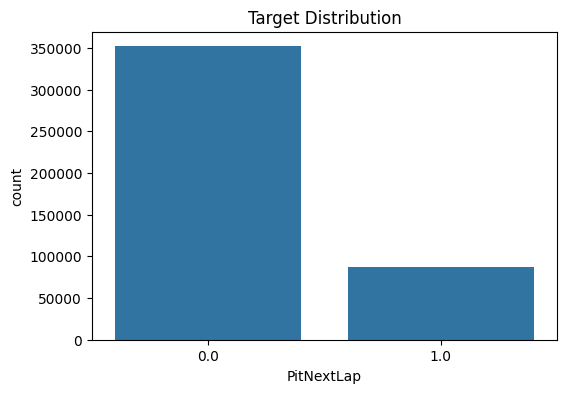

In [90]:
# =============================================================================
# 5. TARGET DISTRIBUTION
# =============================================================================

plt.figure(figsize=(6,4))

sns.countplot(data=train,x="PitNextLap")

plt.title("Target Distribution")

plt.show()

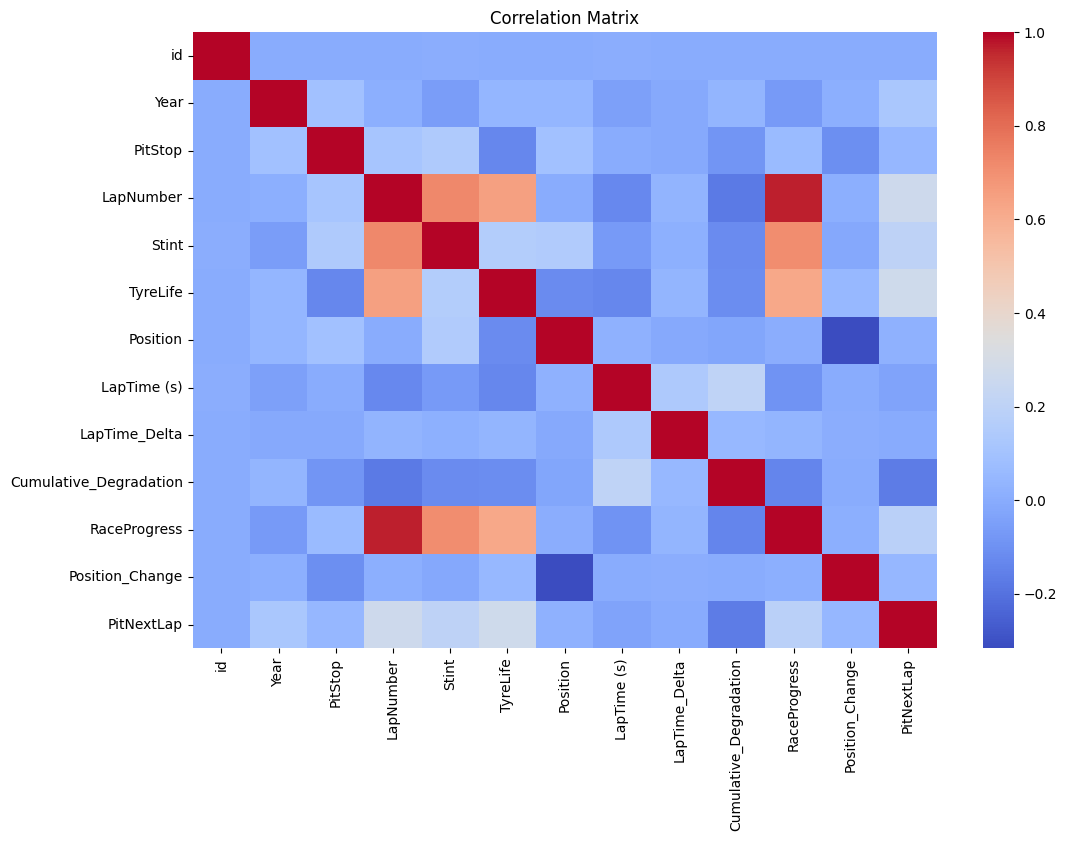

In [91]:
# =============================================================================
# 6. CORRELATION HEATMAP
# =============================================================================

numeric_cols = train.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_cols.corr(),cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

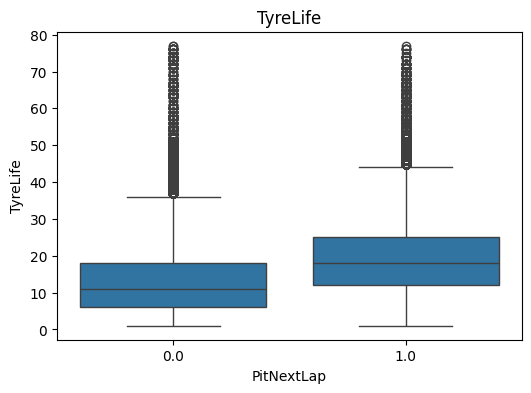

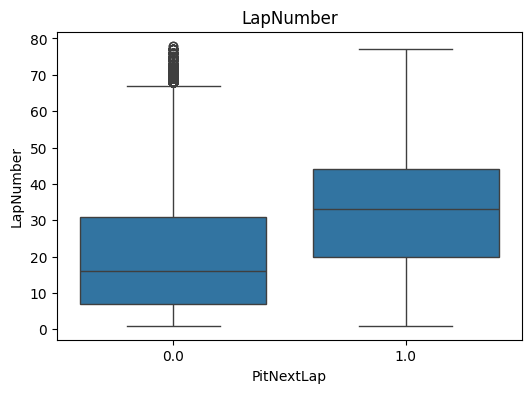

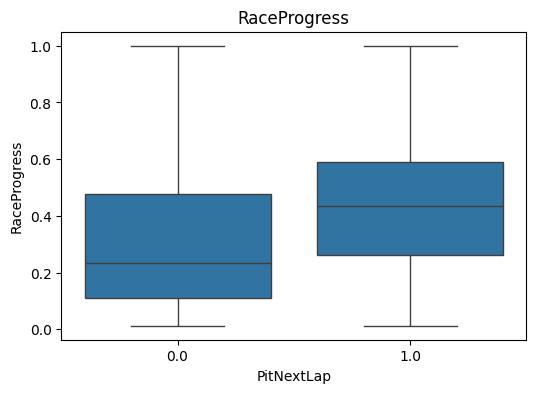

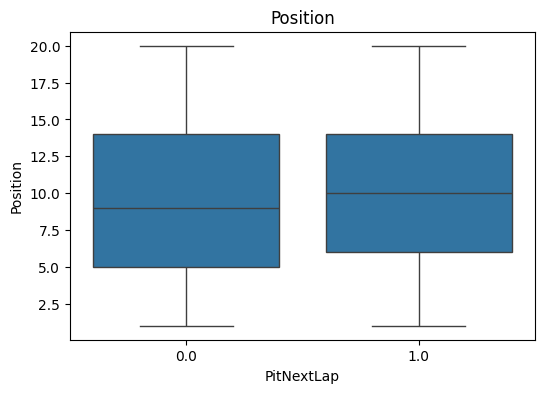

In [92]:
# =============================================================================
# 7. FEATURE ANALYSIS
# =============================================================================

features = ["TyreLife","LapNumber","RaceProgress","Position"]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(data=train,x="PitNextLap",y=col)

    plt.title(col)

    plt.show()

In [93]:
# =============================================================================
# 8. COPY DATA
# =============================================================================

train_df = train.copy()
test_df = test.copy()

In [94]:
# =============================================================================
# 9. FEATURE ENGINEERING
# =============================================================================

driver_freq = train_df["Driver"].value_counts(normalize=True)

race_freq = train_df["Race"].value_counts(normalize=True)

train_df["Driver_freq"] = train_df["Driver"].map(driver_freq)

test_df["Driver_freq"] = (test_df["Driver"].map(driver_freq).fillna(0))

train_df["Race_freq"] = train_df["Race"].map(race_freq)

test_df["Race_freq"] = (test_df["Race"].map(race_freq).fillna(0))

In [95]:
# =============================================================================
# 10. LABEL ENCODING
# =============================================================================

le = LabelEncoder()

train_df["Compound"] = le.fit_transform(train_df["Compound"])

mapping = {cls:i
for i, cls in enumerate(le.classes_)
}

test_df["Compound"] = (test_df["Compound"].map(mapping).fillna(-1))

In [96]:
# =============================================================================
# 11. CREATE INTERACTION FEATURES
# =============================================================================

train_df["TyreLife_x_Degradation"] = (train_df["TyreLife"]*train_df["Cumulative_Degradation"])

test_df["TyreLife_x_Degradation"] = (test_df["TyreLife"]*test_df["Cumulative_Degradation"])

In [97]:
# =============================================================================
# 12. DROP UNUSED COLUMNS
# =============================================================================

drop_cols = ["id","Driver","Race","Year"]

train_df.drop(columns=[c for c in drop_cols if c in train_df.columns],inplace=True)

test_df.drop(columns=[c for c in drop_cols if c in test_df.columns],inplace=True)

In [98]:
# =============================================================================
# 13. HANDLE MISSING VALUES
# =============================================================================

for col in train_df.columns:

    if train_df[col].dtype != "object":

        median_value = train_df[col].median()

        train_df[col] = train_df[col].fillna(
            median_value
        )

        if col in test_df.columns:

            test_df[col] = test_df[col].fillna(
                median_value
            )

In [99]:
train_df.head()

,Compound,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Driver_freq,Race_freq,TyreLife_x_Degradation
0,0,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,0.002345,0.048768,819.741
1,0,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,0.002671,0.055704,-1562.449
2,0,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,0.003336,0.048329,-2211.638
3,2,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,0.003261,0.051218,-14.648
4,0,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,0.003316,0.027613,-84.834


In [100]:
# =============================================================================
# 14. PREPARE FEATURES AND TARGET
# =============================================================================

TARGET = "PitNextLap"

X = train_df.drop(columns=[TARGET])

y = train_df[TARGET]

In [101]:
# =============================================================================
# 15. TRAIN VALIDATION SPLIT
# =============================================================================

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

print(X_train.shape)
print(X_val.shape)

(351312, 14)
(87828, 14)


In [102]:
# =============================================================================
# 16. FEATURE SCALING
# =============================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

In [103]:
# =============================================================================
# 17. TRAIN LOGISTIC REGRESSION
# =============================================================================

lr = LogisticRegression(max_iter=1000, class_weight="balanced")

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_val_scaled)

lr_prob = lr.predict_proba(X_val_scaled)[:,1]

In [104]:
# =============================================================================
# 18. TRAIN RANDOM FOREST
# =============================================================================

rf = RandomForestClassifier(n_estimators=300,max_depth=20,min_samples_leaf=10,class_weight="balanced",random_state=42,n_jobs=-1)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_val)

rf_prob = rf.predict_proba(X_val)[:,1]

In [ ]:
# =============================================================================
# 19. Train XGBoost
# =============================================================================

from xgboost import XGBClassifier
XG = XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric="logloss")

XG.fit(X_train, y_train)

XG_pred = XG.predict(X_val)

XG_prob = XG.predict_proba(X_val)[:,1]

In [ ]:
# =============================================================================
# 20. MODEL EVALUATION
# =============================================================================

def evaluate_model(name,y_true,pred,prob):

    print(f"\n{name}")

    print(classification_report(y_true,pred))

    print("ROC AUC:",roc_auc_score(y_true,prob))

In [ ]:
# =============================================================================
# 21. PRINT RESULTS
# =============================================================================

evaluate_model("Logistic Regression",y_val,lr_pred,lr_prob)

evaluate_model("Random Forest",y_val,rf_pred,rf_prob)

evaluate_model("XGBoost",y_val,XG_pred,XG_prob)



Logistic Regression
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.84     70352
         1.0       0.44      0.77      0.56     17476

    accuracy                           0.76     87828
   macro avg       0.69      0.76      0.70     87828
weighted avg       0.83      0.76      0.78     87828

ROC AUC: 0.8331265992561981

Random Forest
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.91     70352
         1.0       0.63      0.85      0.72     17476

    accuracy                           0.87     87828
   macro avg       0.79      0.86      0.82     87828
weighted avg       0.89      0.87      0.88     87828

ROC AUC: 0.9376467915216959

XGBoost
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93     70352
         1.0       0.73      0.71      0.72     17476

    accuracy                           0.89     87828
   macro avg       0.83    

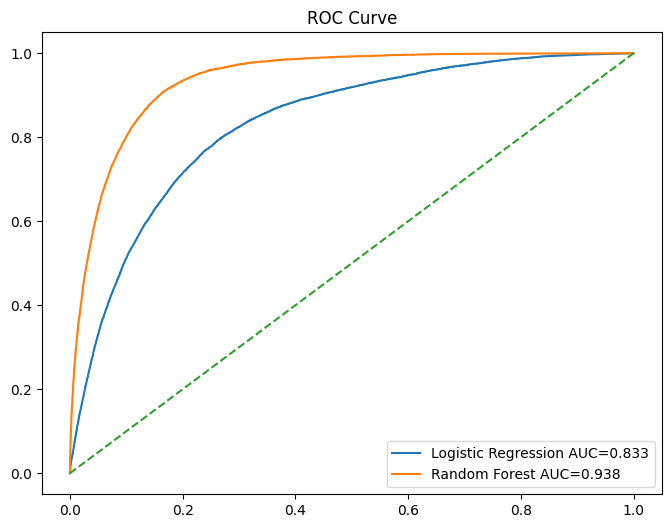

In [ ]:
# =============================================================================
# 22. ROC CURVE
# =============================================================================

plt.figure(figsize=(8,6))

for prob, name in [
    (lr_prob, "Logistic Regression"),
    (rf_prob, "Random Forest")
]:

    fpr, tpr, _ = roc_curve(y_val,prob)

    auc = roc_auc_score(y_val,prob)

    plt.plot(fpr,tpr,label=f"{name} AUC={auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve")

plt.show()

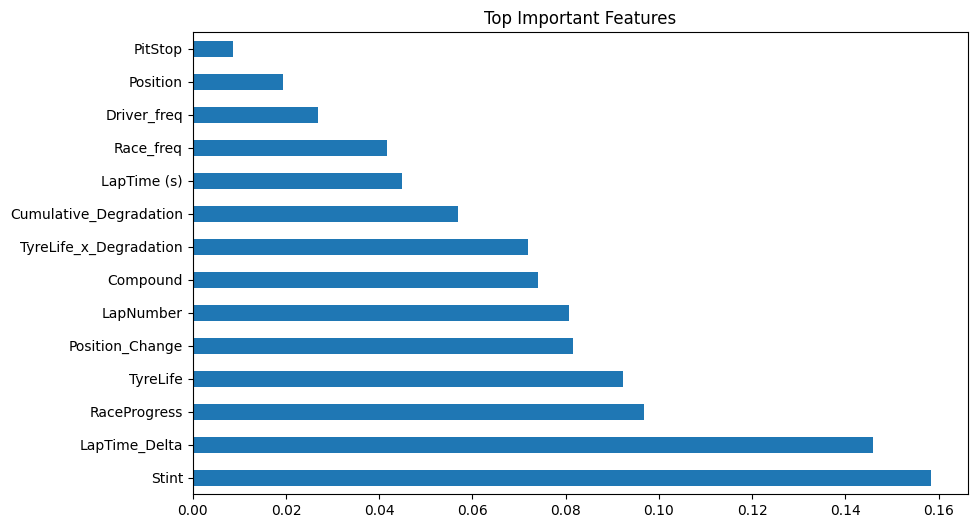

In [ ]:
# =============================================================================
# 23. FEATURE IMPORTANCE
# =============================================================================

importance = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(15).plot(kind="barh")

plt.title("Top Important Features")

plt.show()